BÀI THỰC HÀNH SỐ 01\
Học phần: Thống kê máy tính và Ứng dụng \
Thời gian làm bài: 60 phút\
Lớp học phần: ...\
Họ và tên: ...\
Mã sinh viên: ...

Cho file dữ liệu airlines_flights_data.csv. Hãy thực hiện các yêu cầu sau:
1. Đọc dữ liệu và hiển thị 5 dòng đầu tiên, 10 dòng cuối cùng (1đ).
2. Hiển thị các thuộc tính định tính, các thuộc tính định lượng (1đ).
3. Kiểm tra xem dữ liệu có bị thiếu, bị trùng lặp không, xử lý bằng cách xoá bỏ (nếu có) và kiểm tra kết quả sau khi thực hiện (2đ).
4. Tính các đặc trưng của các thuộc tính định lượng (1đ).
5. Vẽ Boxplot về giá vé (Price) và chỉ ra các giá trị ngoại lệ (nếu có) (1đ).
6. Có bao nhiêu đường bay (source_city đến destination_city)? Tính giá vé trung bình của mỗi đường bay (1đ).
7. Đường bay nào có giá trung bình thấp nhất? giá trung bình bao nhiêu? (1đ).
8. Vẽ đồ thị trực quan giá vé thấp nhất của các đường bay khi mua vào thời điểm cách ngày bay (days_left) 3 ngày (1đ).
9. Tìm đường bay và chuyến bay vào buổi sáng có giá thấp nhất khi mua vé vào thời điểm cách ngày bay 3 ngày? (1đ).

In [3]:

import pandas as pd
df= pd.read_csv("airlines_flights_data.csv")
print (df.head(5))
print(df.tail(10))

   index   airline   flight source_city departure_time stops   arrival_time  \
0      0  SpiceJet  SG-8709       Delhi        Evening  zero          Night   
1      1  SpiceJet  SG-8157       Delhi  Early_Morning  zero        Morning   
2      2   AirAsia   I5-764       Delhi  Early_Morning  zero  Early_Morning   
3      3   Vistara   UK-995       Delhi        Morning  zero      Afternoon   
4      4   Vistara   UK-963       Delhi        Morning  zero        Morning   

  destination_city    class  duration  days_left  price  
0           Mumbai  Economy      2.17          1   5953  
1           Mumbai  Economy      2.33          1   5953  
2           Mumbai  Economy      2.17          1   5956  
3           Mumbai  Economy      2.25          1   5955  
4           Mumbai  Economy      2.33          1   5955  
         index    airline  flight source_city departure_time stops  \
300143  300143  Air_India  AI-440     Chennai  Early_Morning   one   
300144  300144  Air_India  AI-539    

In [4]:
print("Dinh luong")
print(df.select_dtypes(include=['int64','float64']).columns)
print("dinh tinh")
print(df.select_dtypes(include=['object']).columns)

Dinh luong
Index(['index', 'duration', 'days_left', 'price'], dtype='object')
dinh tinh
Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class'],
      dtype='object')


In [21]:
print(df.isnull().sum())
df=df.dropna()
df.duplicated().sum()
df=df.drop_duplicates()
print(df.info())

index               0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-nu

In [12]:
df.describe()

,index,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


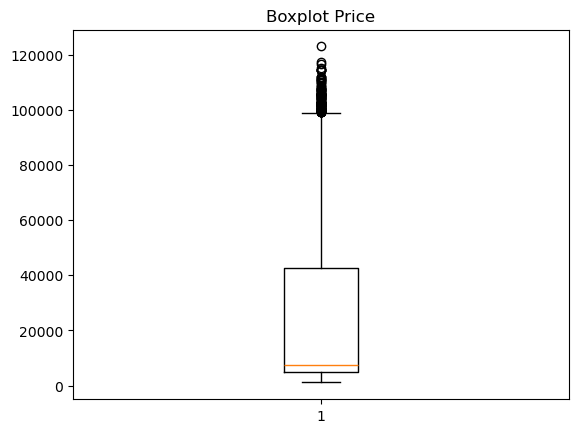

In [15]:
import matplotlib.pyplot as plt
plt.boxplot(df['price'])
plt.title("Boxplot Price")
plt.show()

In [33]:
df['route'] = df['source_city'] +"-"+ df['destination_city']
print("so duong bay: ",
df['route'].nunique())
avg_price=df.groupby('route')['price'].mean()
print(avg_price)

so duong bay:  30
route
Bangalore-Chennai      23321.850078
Bangalore-Delhi        17723.313972
Bangalore-Hyderabad    21226.121192
Bangalore-Kolkata      23500.061229
Bangalore-Mumbai       23128.618672
Chennai-Bangalore      25081.850454
Chennai-Delhi          18981.863948
Chennai-Hyderabad      21591.345404
Chennai-Kolkata        22669.932407
Chennai-Mumbai         22765.849647
Delhi-Bangalore        17880.216315
Delhi-Chennai          19369.881354
Delhi-Hyderabad        17347.288379
Delhi-Kolkata          20566.409418
Delhi-Mumbai           19355.829812
Hyderabad-Bangalore    21347.177998
Hyderabad-Chennai      21848.065989
Hyderabad-Delhi        17243.945685
Hyderabad-Kolkata      20823.893201
Hyderabad-Mumbai       20080.865759
Kolkata-Bangalore      22744.808428
Kolkata-Chennai        23660.361040
Kolkata-Delhi          19422.354559
Kolkata-Hyderabad      21500.011397
Kolkata-Mumbai         22078.883579
Mumbai-Bangalore       23147.873807
Mumbai-Chennai         22781.899112
Mumb

In [34]:
avg_price=df.groupby('route')['price'].mean()
print(avg_price.idxmin())
print(avg_price.min())

Hyderabad-Delhi
17243.945685398543


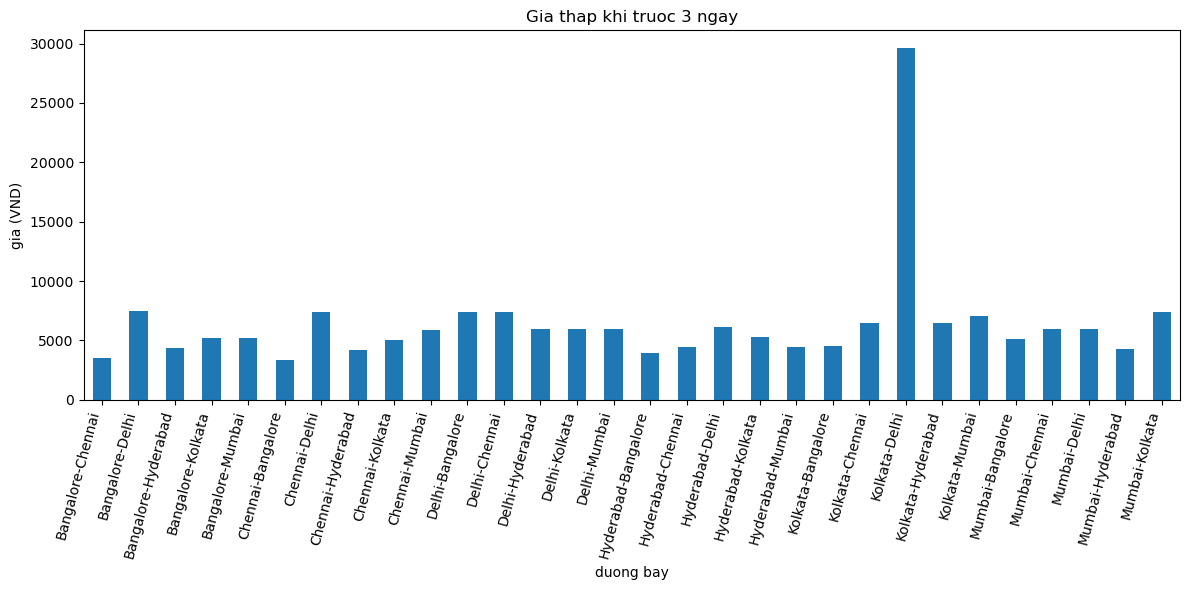

In [38]:
df3=df[df['days_left'] == 3]
min_price = df3.groupby('route')['price'].min()
min_price.plot(kind='bar', figsize =(12,6))
plt.title("Gia thap khi truoc 3 ngay")
plt.ylabel("gia (VND)")
plt.xlabel("duong bay")
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

In [40]:
df_morning = df[(df['departure_time'] =='morning') & (df['days_left'] == 3)]
cheapest = df_morning.loc[df_morning['price'].idxmin()]
print(cheapest)

ValueError: attempt to get argmin of an empty sequence